# Wedding-day timeline risk

This notebook runs the current schedule through a dependency-aware Monte Carlo simulation. Clock times are earliest starts; delays propagate only through explicit prerequisites. Edit `default_timeline()` in `src/wedding_sim/timeline/inputs.py` as vendor estimates improve.

In [1]:
from wedding_sim.timeline import default_timeline, format_timeline_result, minutes_to_clock, simulate_timeline
from wedding_sim.timeline.visualization import plot_delay_risk, plot_timeline

events = default_timeline()
result = simulate_timeline(events, trials=10_000, seed=42)
print(format_timeline_result(result))

Wedding timeline Monte Carlo (10,000 trials)
Ceremony starts on time: 5.5%
Ceremony starts >10 min late: 50.7%
Dessert served before Bus 1 boarding: 70.0%
Expected buffer before Bus 1 boarding: 6.7 min
10th-percentile buffer before Bus 1 boarding: -10.9 min

Selected event starts (planned / median / 90th percentile):
  First-look portraits: 1:00 PM / 1:09 PM / 1:16 PM
  Wedding ceremony: 4:30 PM / 4:40 PM / 4:54 PM
  Grand entrance: wedding couple: 6:13 PM / 6:33 PM / 6:48 PM
  Main course: 7:57 PM / 8:24 PM / 8:40 PM
  Dessert served: 9:35 PM / 10:07 PM / 10:25 PM


## Full-day view

Each bar is the planned activity duration. The dot is its expected simulated finish; the line extends to its 90th-percentile finish.

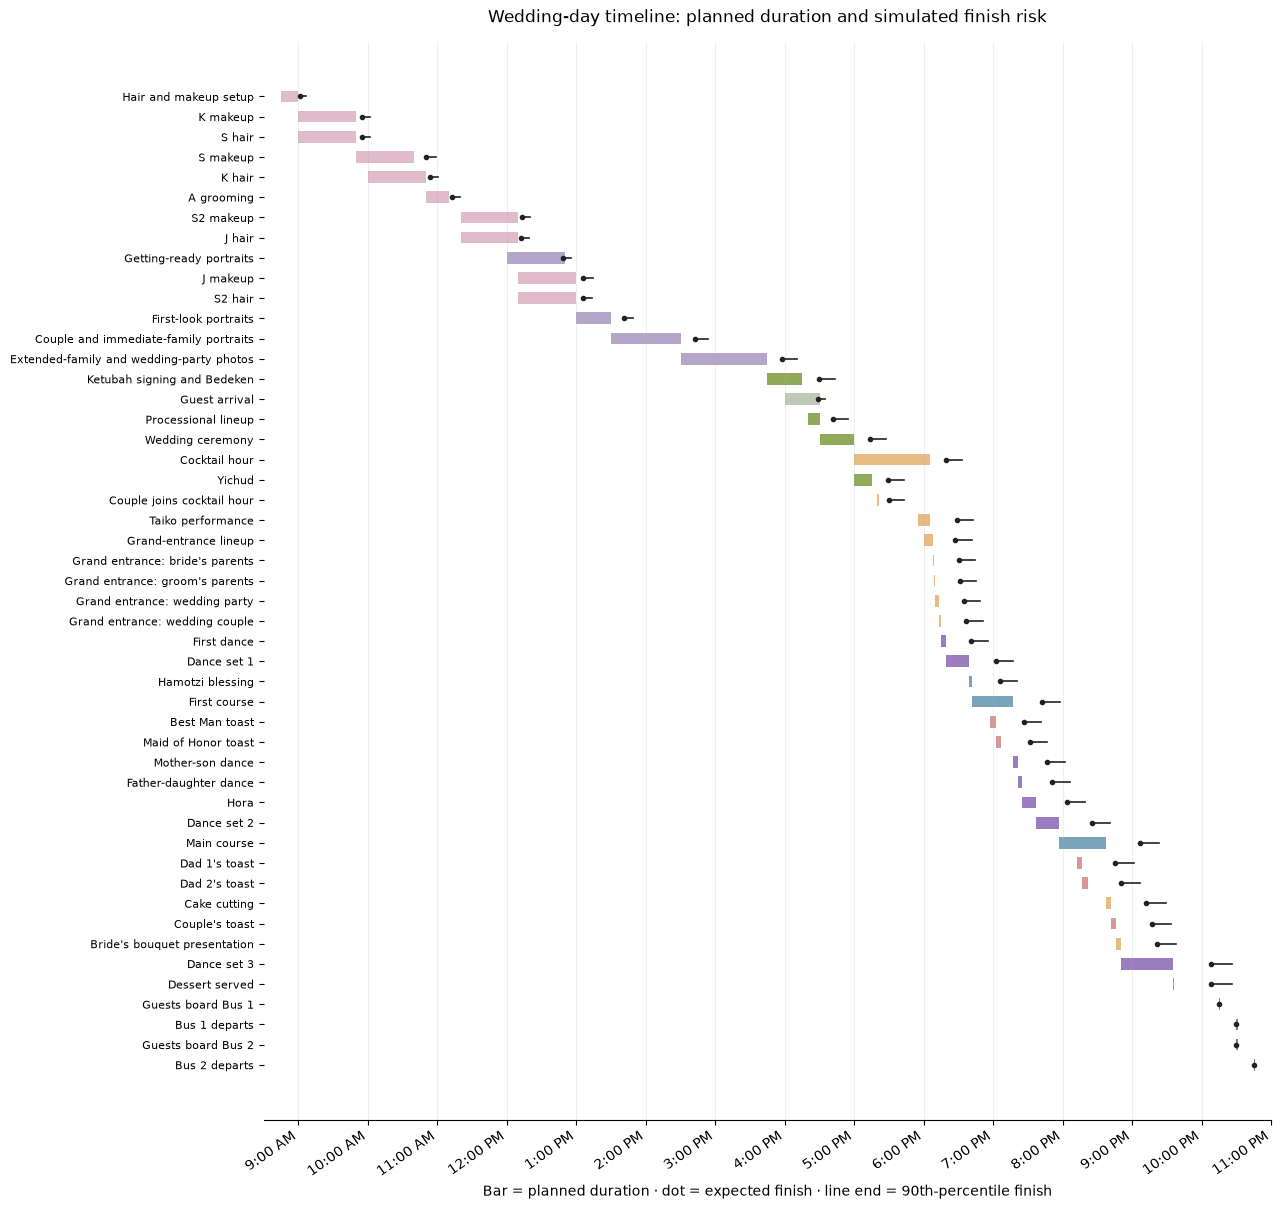

In [2]:
plot_timeline(result);

## Events exposed to accumulated delay

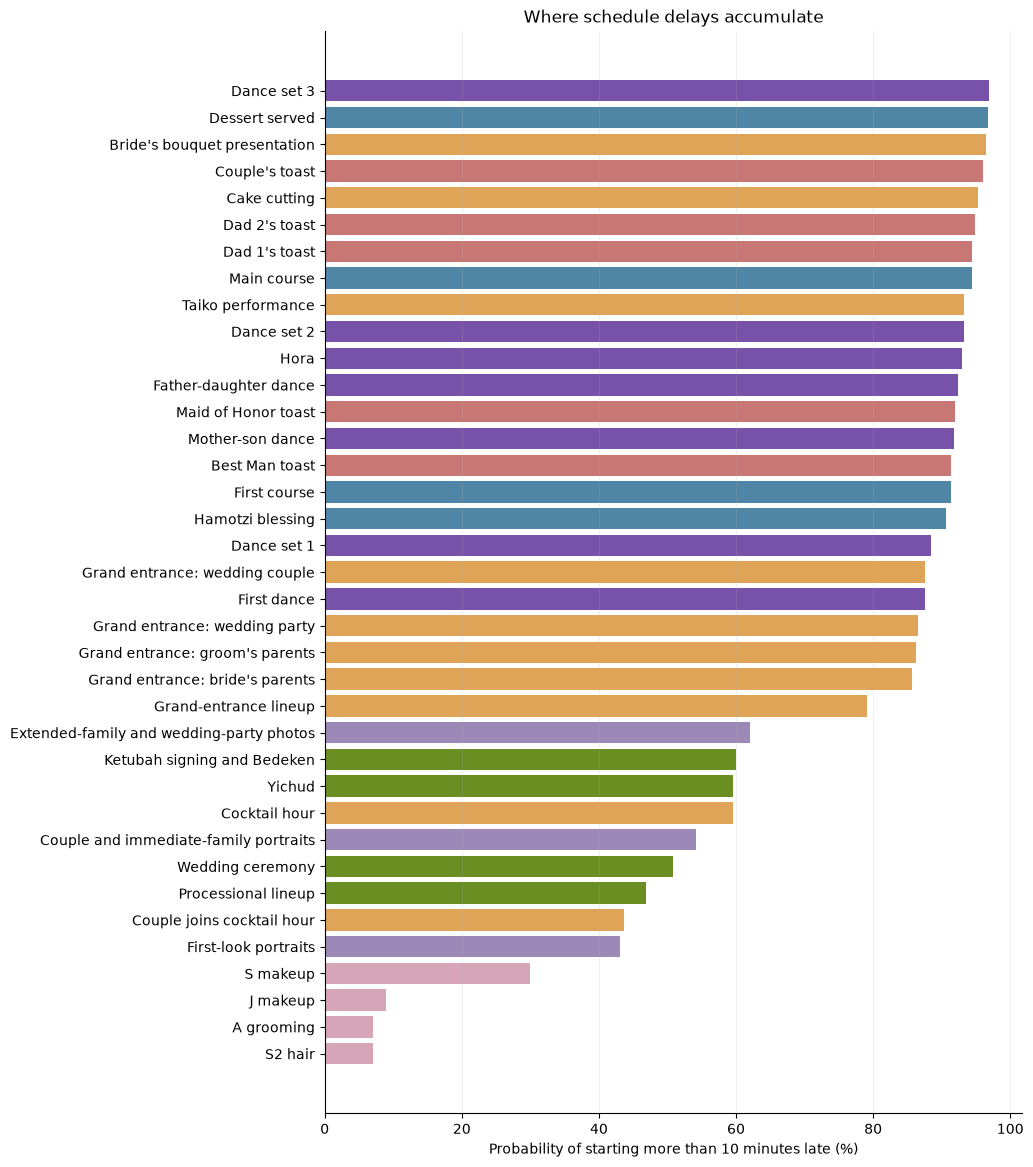

In [3]:
plot_delay_risk(result);

## Inspect the numbers

This dependency-free table is useful when discussing buffers with the planner and vendors.

In [4]:
rows = sorted(result.events, key=lambda event: event.over_10_minutes_late_probability, reverse=True)[:15]
for event in rows:
    print(f"{event.label:48} {event.over_10_minutes_late_probability:6.1%}  P90 finish {minutes_to_clock(event.p90_end_minutes)}")

Dance set 3                                       96.9%  P90 finish 10:25 PM
Dessert served                                    96.7%  P90 finish 10:25 PM
Bride's bouquet presentation                      96.5%  P90 finish 9:38 PM
Couple's toast                                    96.0%  P90 finish 9:33 PM
Cake cutting                                      95.3%  P90 finish 9:28 PM
Dad 2's toast                                     94.8%  P90 finish 9:06 PM
Main course                                       94.5%  P90 finish 9:23 PM
Dad 1's toast                                     94.5%  P90 finish 9:01 PM
Taiko performance                                 93.3%  P90 finish 6:42 PM
Dance set 2                                       93.3%  P90 finish 8:40 PM
Hora                                              92.9%  P90 finish 8:18 PM
Father-daughter dance                             92.4%  P90 finish 8:06 PM
Maid of Honor toast                               92.0%  P90 finish 7:46 PM
Mother-son

## Actual day vs. simulation

Recorded start times live in `src/wedding_sim/timeline/data/actual_starts.csv` (one row per event, 24-hour clock). Each row below compares the recorded start with the event's planned start and its simulated P50–P90 start band.

In [5]:
from IPython.display import HTML

from wedding_sim.timeline import compare_to_actuals
from wedding_sim.timeline.visualization import comparison_html

comparisons = compare_to_actuals(result)
HTML(comparison_html(comparisons))

Event,Planned,Sim P50,Sim P90,Actual,vs plan,vs P90
A grooming,10:50 AM,10:50 AM,10:59 AM,11:00 AM,+10,▲ +1.3
S2 makeup,11:20 AM,11:20 AM,11:20 AM,11:20 AM,±0,within
Getting-ready portraits,12:00 PM,12:00 PM,12:00 PM,12:00 PM,±0,within
First-look portraits,1:00 PM,1:09 PM,1:16 PM,1:20 PM,+20,▲ +3.6
Couple and immediate-family portraits,1:30 PM,1:41 PM,1:49 PM,1:45 PM,+15,within
Extended-family and wedding-party photos,2:30 PM,2:42 PM,2:53 PM,2:30 PM,±0,within
Ketubah signing and Bedeken,3:45 PM,3:58 PM,4:11 PM,3:55 PM,+10,within
Guest arrival,4:00 PM,4:00 PM,4:00 PM,4:00 PM,±0,within
Wedding ceremony,4:30 PM,4:40 PM,4:54 PM,4:43 PM,+13,within
Cocktail hour,5:00 PM,5:13 PM,5:27 PM,5:20 PM,+20,within


### What the comparison shows

Planned times are the clock times in `inputs.py`; events without one (the reception program after taiko) take a planned time derived from the preceding clock times and most-likely durations.

- **Every recorded start was at or before its simulated P50.** With the current inputs the model expects the day to run 40–60 minutes behind plan; the actual day ran 10–40 minutes behind.
- **Morning and ceremony:** first look +20, immediate family +15, ketubah +10, ceremony +13 (4:43 PM against a simulated median of 5:15 PM).
- **Reception:** taiko started 30 minutes late and the program stayed 15–40 minutes behind plan from there, peaking at the dad toasts (+38, +40). Dance set 3 absorbed the delay and both buses left on time.

**Reading this:** the simulation is now more pessimistic than the day turned out. Its most-likely durations, or the A grooming → S makeup chain added to the inputs, overstate how much morning delay carries into the ceremony.